## CFG to PDA Converter

This conversion from a context-free grammar (CFG) to a pushdown automata (PDA) is inspired by the approach from Michael Sipser.

In [92]:
from automata.pda.npda import NPDA

We will make a PDA for the following context-free language:
* S -> ATb | b
* A -> TA | ${\epsilon}$

In [93]:
grammar = {
    "S":["aTb", "b"],
    "T":["Ta", "e"],
}

First, we add a novel character `$` to the stack, followed by the input character.

In [94]:
states={'qStart', 'q0', 'qLoop', 'qAccept'}

transitions = {
    'qStart': {
            '': {'': {('q0', '$')}},  # push '$' to (currently empty) stack
        },
    'q0': {
            '': {'': {('qLoop', 'S')}},  # push '#' to (currently empty) stack
        },
    'qLoop': {
            '': {'$': {('qAccept', '')}}
        },
}

In [95]:
all_rules = [item for sublist in [rules for rules in grammar.values()] for item in sublist]
vars_and_terminals = list(set([item for sublist in all_rules for item in sublist]).union(set(grammar.keys())))
terminals = [x for x in vars_and_terminals if (x.islower() and x != 'e')]

Now, let's consider the particulars of our particular grammar.

In [96]:
# counter for creating new states
state_counter = 1

# process grammar rules
for variable, rules in grammar.items():
    if "qLoop" not in transitions:
        transitions["qLoop"] = {}
    
    # transitions for empty string if not already present
    if "" not in transitions["qLoop"]:
        transitions["qLoop"][""] = {}
    
    for rule in rules:
        reversed_rule = rule[::-1] # stacks are LIFO
        if rule == "e":  # Empty rule
            # pop the LHS, push nothing
            if variable not in transitions["qLoop"][""]:
                transitions["qLoop"][""][variable] = set()
            transitions["qLoop"][""][variable].add(("qLoop", ""))
        
        # longer rules
        else:
            if variable not in transitions["qLoop"][""]:
                transitions["qLoop"][""][variable] = set()
            
            # ift there's a single symbol, push it
            if len(rule) == 1:
                transitions["qLoop"][""][variable].add(("qLoop", rule))
            else:
                # othersiwe, create intermediate states
                first_state = f"q{state_counter}"
                state_counter += 1
                states.add(first_state)
                transitions["qLoop"][""][variable].add((first_state, reversed_rule[0]))
                
                # Create intermediate states for each remaining symbol
                prev_state = first_state
                for i in range(1, len(rule)):
                    # Create a new state ala Sipser's algorithm
                    new_state = f"q{state_counter}" if i < len(rule) - 1 else "qLoop"
                    if i < len(rule) - 1:
                        states.add(new_state)
                        state_counter += 1
                    
                    # Add transition from previous state to new state
                    if prev_state not in transitions:
                        transitions[prev_state] = {"": {}}
                    if "" not in transitions[prev_state]:
                        transitions[prev_state][""] = {}
                    if "" not in transitions[prev_state][""]:
                        transitions[prev_state][""][""] = set()
                    
                    # make sure to use the reversed rule, because stacks are LIFO
                    transitions[prev_state][""][""].add((new_state, reversed_rule[i]))
                    prev_state = new_state

# Add transitions for terminal symbols
for terminal in terminals:
    if terminal not in transitions["qLoop"]:
        transitions["qLoop"][terminal] = {}
    
    if terminal not in transitions["qLoop"][terminal]:
        transitions["qLoop"][terminal][terminal] = set()
    
    transitions["qLoop"][terminal][terminal].add(("qLoop", ""))

In [97]:
for key, item in transitions.items():
    print(key)
    for j,k in item.items():
        print(j, k)

qStart
 {'': {('q0', '$')}}
q0
 {'': {('qLoop', 'S')}}
qLoop
 {'$': {('qAccept', '')}, 'S': {('qLoop', 'b'), ('q1', 'b')}, 'T': {('q3', 'a'), ('qLoop', '')}}
b {'b': {('qLoop', '')}}
a {'a': {('qLoop', '')}}
q1
 {'': {('q2', 'T')}}
q2
 {'': {('qLoop', 'a')}}
q3
 {'': {('qLoop', 'T')}}


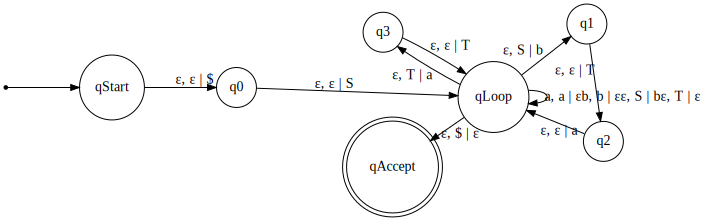

In [98]:
npda = NPDA(
    states=states,
    input_symbols=terminals,
    stack_symbols={'$', ''}.union(set(vars_and_terminals)),
    transitions=transitions,
    initial_state='qStart',
    initial_stack_symbol='$',
    final_states={'qAccept'},
    acceptance_mode='final_state'
)

npda.show_diagram(state_separation=4, layout_method="circo", fig_size=(500,500), path="output/pda_1.png")